In [19]:
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import pandas as pd
from collections import (defaultdict,Counter)
import matplotlib.pyplot as plt
import scipy  
from scipy import stats


In [1]:
import pickle as pk

In [15]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

def overlap_genelists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))



#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [4]:
#Let's import the ICD-gene associations
with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [12]:
G_elma_icd_female_df = pd.read_csv('output/G_elma_icd_female_df.tsv', sep="\t",index_col=0)
G_elma_icd_male_df = pd.read_csv('output/G_elma_icd_male_df.tsv', sep="\t",index_col=0)

In [14]:
G_elma_icd_male_df

,Dis A,Dis B
0,K35,K37
1,K35,K56
2,K35,K65
3,K37,K56
4,K37,K65
...,...,...
1276,I70,I73
1277,J91,J94
1278,C80,D63
1279,D31,H04


In [5]:
with open('output/female_trajectories_dis_sort_bytime_grouped_all_add_dict.pickle', 'rb') as handle:
    female_trajectories_dis_sort_bytime_grouped_all_add_dict = pk.load(handle)

with open('output/female_trajectories_dict_filtered.pickle', 'rb') as handle:
    female_trajectories_dict_filtered = pk.load(handle)

with open('output/female_trajectories_dict_filtered_unique.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique = pk.load(handle)


with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_dict.pickle', 'rb') as handle:
    male_trajectories_dis_sort_bytime_grouped_all_add_dict = pk.load(handle)

with open('output/male_trajectories_dict_filtered.pickle', 'rb') as handle:
    male_trajectories_dict_filtered = pk.load(handle)

with open('output/male_trajectories_dict_filtered_unique.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique = pk.load(handle)
    

In [69]:
female_dis_pair_phase_dict = {}
for i,v in G_elma_icd_female_df.iterrows():
    dis_a = v['Dis A']
    dis_b = v['Dis B']
    phase_dict = {}
    trj_list = []
    # Step 1: Identify trajectories containing both diseases
    for trj, dislist in female_trajectories_dict_filtered_unique.items():
        if dis_a in dislist and dis_b in dislist:
            trj_list.append(trj)
    cl_trj_list = []     
    for trj in trj_list:
        if "_" not in trj:
            cl_trj_list.append(trj)
        else:
            for cl_trj in trj.split("_"):
                cl_trj_list.append(cl_trj)
                
    
    same_time = []
    a_previous_b = []
    b_previous_a = []
    
    # Step 2: Analyze the trajectories to determine the relative occurrence of the diseases
    for trj in cl_trj_list:
        ph_trj_dict = female_trajectories_dis_sort_bytime_grouped_all_add_dict[int(trj)]
        found_same_time = False
        found_a_before_b = False
        found_b_before_a = False
    
        # Iterate over the stages in order
        for ph1, dislist1 in ph_trj_dict.items():
            # Check if both diseases occur in the same stage
            if dis_a in dislist1 and dis_b in dislist1:
                same_time.append(trj)
                found_same_time = True
                break  # No need to check further if they're in the same stage
    
        # If not same_time, check for a before b and b before a
        if not found_same_time:
            for ph1, dislist1 in ph_trj_dict.items():
                if dis_a in dislist1:
                    # Check if b occurs in a later stage
                    for ph2 in range(ph1 + 1, len(ph_trj_dict) + 1):
                        if dis_b in ph_trj_dict[ph2]:
                            a_previous_b.append(trj)
                            found_a_before_b = True
                            break
                if dis_b in dislist1 and not found_a_before_b:
                    # Check if a occurs in a later stage
                    for ph2 in range(ph1 + 1, len(ph_trj_dict) + 1):
                        if dis_a in ph_trj_dict[ph2]:
                            b_previous_a.append(trj)
                            found_b_before_a = True
                            break
                # Stop checking once either condition is satisfied
                if found_a_before_b or found_b_before_a:
                    break
    
    # Step 3: Calculate proportions
    total_trajectories = len(cl_trj_list)
    same_time_proportion = len(set(same_time)) / total_trajectories if total_trajectories > 0 else 0
    a_before_b_proportion = len(set(a_previous_b)) / total_trajectories if total_trajectories > 0 else 0
    b_before_a_proportion = len(set(b_previous_a)) / total_trajectories if total_trajectories > 0 else 0
    phase_dict["A & B same time"]=same_time_proportion
    phase_dict["A before B"]=a_before_b_proportion
    phase_dict["B before A"]=b_before_a_proportion
    female_dis_pair_phase_dict[dis_a,dis_b] = phase_dict
    


In [70]:
with open('output/female_dis_pair_phase_dict.pickle', 'wb') as handle:
    pk.dump(female_dis_pair_phase_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [75]:
male_dis_pair_phase_dict = {}
for i,v in G_elma_icd_male_df.iterrows():
    dis_a = v['Dis A']
    dis_b = v['Dis B']
    phase_dict = {}
    trj_list = []
    # Step 1: Identify trajectories containing both diseases
    for trj, dislist in male_trajectories_dict_filtered_unique.items():
        if dis_a in dislist and dis_b in dislist:
            trj_list.append(trj)
    cl_trj_list = []     
    for trj in trj_list:
        if "_" not in trj:
            cl_trj_list.append(trj)
        else:
            for cl_trj in trj.split("_"):
                cl_trj_list.append(cl_trj)
                
    
    same_time = []
    a_previous_b = []
    b_previous_a = []
    
    # Step 2: Analyze the trajectories to determine the relative occurrence of the diseases
    for trj in cl_trj_list:
        ph_trj_dict = male_trajectories_dis_sort_bytime_grouped_all_add_dict[int(trj)]
        found_same_time = False
        found_a_before_b = False
        found_b_before_a = False
    
        # Iterate over the stages in order
        for ph1, dislist1 in ph_trj_dict.items():
            # Check if both diseases occur in the same stage
            if dis_a in dislist1 and dis_b in dislist1:
                same_time.append(trj)
                found_same_time = True
                break  # No need to check further if they're in the same stage
    
        # If not same_time, check for a before b and b before a
        if not found_same_time:
            for ph1, dislist1 in ph_trj_dict.items():
                if dis_a in dislist1:
                    # Check if b occurs in a later stage
                    for ph2 in range(ph1 + 1, len(ph_trj_dict) + 1):
                        if dis_b in ph_trj_dict[ph2]:
                            a_previous_b.append(trj)
                            found_a_before_b = True
                            break
                if dis_b in dislist1 and not found_a_before_b:
                    # Check if a occurs in a later stage
                    for ph2 in range(ph1 + 1, len(ph_trj_dict) + 1):
                        if dis_a in ph_trj_dict[ph2]:
                            b_previous_a.append(trj)
                            found_b_before_a = True
                            break
                # Stop checking once either condition is satisfied
                if found_a_before_b or found_b_before_a:
                    break
    
    # Step 3: Calculate proportions
    total_trajectories = len(cl_trj_list)
    same_time_proportion = len(set(same_time)) / total_trajectories if total_trajectories > 0 else 0
    a_before_b_proportion = len(set(a_previous_b)) / total_trajectories if total_trajectories > 0 else 0
    b_before_a_proportion = len(set(b_previous_a)) / total_trajectories if total_trajectories > 0 else 0
    phase_dict["A & B same time"]=same_time_proportion
    phase_dict["A before B"]=a_before_b_proportion
    phase_dict["B before A"]=b_before_a_proportion
    male_dis_pair_phase_dict[dis_a,dis_b] = phase_dict
    


In [76]:
with open('output/male_dis_pair_phase_dict.pickle', 'wb') as handle:
    pk.dump(male_dis_pair_phase_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [3]:
with open('output/male_dis_pair_phase_dict.pickle', 'rb') as handle:
    male_dis_pair_phase_dict = pk.load(handle)

In [6]:
male_dis_pair_phase_dict[("E66","E11")]

{'A & B same time': 1.0, 'A before B': 0.0, 'B before A': 0.0}

In [66]:
G_elma_icd_female_genetic_jaccard_dict = {}
G_elma_icd_female_genetic_pval_dict={}

for i,v in G_elma_icd_female_df.iterrows():
    dis_a = v['Dis A']
    dis_b = v['Dis B']
    genelist_a = allsources_icd_gene_dict_unified[dis_a]
    genelist_b = allsources_icd_gene_dict_unified[dis_b]
    ji_weight= overlap_jaccard(genelist_a,genelist_b)
    G_elma_icd_female_genetic_jaccard_dict[dis_a,dis_b] = ji_weight
    pval_ov=float(overlap_genelists(genelist_a,genelist_b,24008)) #24008 is the total number of genes
    G_elma_icd_female_genetic_pval_dict[dis_a,dis_b] = pval_ov


G_elma_icd_female_genetic_fdr_dict = {}
adj_pval=fdr_adjustment(list(G_elma_icd_female_genetic_pval_dict.values()),0.05)
pair_list=list(G_elma_icd_female_genetic_pval_dict.keys())
for i in range(len(adj_pval)):
    G_elma_icd_female_genetic_fdr_dict[pair_list[i]]=adj_pval[i]
        


In [71]:
with open('output/G_elma_icd_female_genetic_jaccard_dict.pickle', 'wb') as handle:
    pk.dump(G_elma_icd_female_genetic_jaccard_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/G_elma_icd_female_genetic_fdr_dict.pickle', 'wb') as handle:
    pk.dump(G_elma_icd_female_genetic_fdr_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [6]:
with open('output/G_elma_icd_female_genetic_jaccard_dict.pickle', 'rb') as handle:
    G_elma_icd_female_genetic_jaccard_dict = pk.load(handle)

with open('output/G_elma_icd_female_genetic_fdr_dict.pickle', 'rb') as handle:
    G_elma_icd_female_genetic_fdr_dict = pk.load(handle)

In [77]:
G_elma_icd_male_genetic_jaccard_dict = {}
G_elma_icd_male_genetic_pval_dict={}

for i,v in G_elma_icd_male_df.iterrows():
    dis_a = v['Dis A']
    dis_b = v['Dis B']
    genelist_a = allsources_icd_gene_dict_unified[dis_a]
    genelist_b = allsources_icd_gene_dict_unified[dis_b]
    ji_weight= overlap_jaccard(genelist_a,genelist_b)
    G_elma_icd_male_genetic_jaccard_dict[dis_a,dis_b] = ji_weight
    pval_ov=float(overlap_genelists(genelist_a,genelist_b,24008)) #24008 is the total number of genes
    G_elma_icd_male_genetic_pval_dict[dis_a,dis_b] = pval_ov


G_elma_icd_male_genetic_fdr_dict = {}
adj_pval=fdr_adjustment(list(G_elma_icd_male_genetic_pval_dict.values()),0.05)
pair_list=list(G_elma_icd_male_genetic_pval_dict.keys())
for i in range(len(adj_pval)):
    G_elma_icd_male_genetic_fdr_dict[pair_list[i]]=adj_pval[i]
        


In [78]:
with open('output/G_elma_icd_male_genetic_jaccard_dict.pickle', 'wb') as handle:
    pk.dump(G_elma_icd_male_genetic_jaccard_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/G_elma_icd_male_genetic_fdr_dict.pickle', 'wb') as handle:
    pk.dump(G_elma_icd_male_genetic_fdr_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [2]:
with open('output/G_elma_icd_male_genetic_jaccard_dict.pickle', 'rb') as handle:
    G_elma_icd_male_genetic_jaccard_dict = pk.load(handle)

with open('output/G_elma_icd_male_genetic_fdr_dict.pickle', 'rb') as handle:
    G_elma_icd_male_genetic_fdr_dict = pk.load(handle)

In [10]:
len(G_elma_icd_male_genetic_jaccard_dict)

1281

In [9]:
len(G_elma_icd_male_genetic_fdr_dict)

1281

In [4]:

dict(sorted(G_elma_icd_male_genetic_fdr_dict.items(), key=lambda item: item[1]))


{('E10', 'E14'): np.float64(0.0),
 ('E88', 'F54'): np.float64(0.0),
 ('J18', 'J15'): np.float64(0.0),
 ('B99', 'G93'): np.float64(0.0),
 ('C19', 'C20'): np.float64(0.0),
 ('C19', 'C21'): np.float64(0.0),
 ('C19', 'C48'): np.float64(0.0),
 ('C20', 'C21'): np.float64(0.0),
 ('C20', 'C48'): np.float64(0.0),
 ('C21', 'C48'): np.float64(0.0),
 ('D48', 'C34'): np.float64(0.0),
 ('D48', 'C80'): np.float64(0.0),
 ('D48', 'D63'): np.float64(0.0),
 ('D73', 'L28'): np.float64(0.0),
 ('C34', 'C80'): np.float64(0.0),
 ('C09', 'C10'): np.float64(0.0),
 ('C67', 'C66'): np.float64(0.0),
 ('C80', 'D63'): np.float64(0.0),
 ('C83', 'C85'): np.float64(5.083319262899841e-301),
 ('F80', 'F83'): np.float64(6.514828798316002e-269),
 ('A08', 'B09'): np.float64(1.404157009749087e-264),
 ('C82', 'C85'): np.float64(8.500145732161765e-260),
 ('I42', 'I51'): np.float64(2.8587834926606273e-257),
 ('C82', 'C83'): np.float64(1.0541877632709051e-254),
 ('C34', 'D63'): np.float64(1.1633795017569423e-238),
 ('F20', 'F31'

In [11]:
len(G_elma_icd_female_genetic_jaccard_dict)

1189

In [12]:
len(G_elma_icd_female_genetic_fdr_dict)

1189

In [13]:
G_elma_icd_female_genetic_jaccard_dict

{('I88', 'K56'): 0.0,
 ('I88', 'K59'): 0.0,
 ('I88', 'K60'): 0.0,
 ('I88', 'K02'): 0.0,
 ('I88', 'K04'): 0.0,
 ('K56', 'K59'): 0.0196078431372549,
 ('K56', 'K60'): 0.0,
 ('K56', 'K50'): 0.0,
 ('K56', 'K63'): 0.015384615384615385,
 ('K56', 'K65'): 0.0,
 ('K56', 'C48'): 0.0,
 ('K59', 'K60'): 0.011494252873563218,
 ('K59', 'B37'): 0.0,
 ('K59', 'E65'): 0.0,
 ('K59', 'L90'): 0.0,
 ('K59', 'N62'): 0.0,
 ('K59', 'H10'): 0.0,
 ('K59', 'F33'): 0.009523809523809525,
 ('K59', 'F41'): 0.0,
 ('K59', 'F43'): 0.02,
 ('K59', 'F45'): 0.0,
 ('K60', 'I84'): 0.009009009009009009,
 ('K60', 'K61'): 0.0,
 ('K60', 'K62'): 0.0,
 ('K60', 'K64'): 0.008928571428571428,
 ('A08', 'A38'): 0.16666666666666666,
 ('A08', 'B01'): 0.0,
 ('A08', 'H61'): 0.011401917595231926,
 ('A08', 'E86'): 0.0,
 ('A08', 'A09'): 0.0,
 ('A38', 'B01'): 0.006578947368421052,
 ('A38', 'H61'): 0.007729966503478485,
 ('B01', 'H61'): 0.0023370553103090105,
 ('H61', 'D68'): 0.0039380414807035965,
 ('H61', 'H65'): 0.0020844189682126106,
 ('H61',

In [14]:
G_elma_icd_female_genetic_fdr_dict

{('I88', 'K56'): np.float64(1.0),
 ('I88', 'K59'): np.float64(1.0),
 ('I88', 'K60'): np.float64(1.0),
 ('I88', 'K02'): np.float64(1.0),
 ('I88', 'K04'): np.float64(1.0),
 ('K56', 'K59'): np.float64(0.0220215060661927),
 ('K56', 'K60'): np.float64(1.0),
 ('K56', 'K50'): np.float64(1.0),
 ('K56', 'K63'): np.float64(0.027495516456742607),
 ('K56', 'K65'): np.float64(1.0),
 ('K56', 'C48'): np.float64(1.0),
 ('K59', 'K60'): np.float64(0.1720766533223003),
 ('K59', 'B37'): np.float64(1.0),
 ('K59', 'E65'): np.float64(1.0),
 ('K59', 'L90'): np.float64(1.0),
 ('K59', 'N62'): np.float64(1.0),
 ('K59', 'H10'): np.float64(1.0),
 ('K59', 'F33'): np.float64(0.09996380653760947),
 ('K59', 'F41'): np.float64(1.0),
 ('K59', 'F43'): np.float64(0.01694466875863884),
 ('K59', 'F45'): np.float64(1.0),
 ('K60', 'I84'): np.float64(0.24358525804955203),
 ('K60', 'K61'): np.float64(1.0),
 ('K60', 'K62'): np.float64(1.0),
 ('K60', 'K64'): np.float64(0.09062827228492748),
 ('A08', 'A38'): np.float64(5.420799095

In [17]:
for dispair,ji in G_elma_icd_female_genetic_jaccard_dict.items():
    if ji<0.01 and G_elma_icd_female_genetic_fdr_dict[dispair]<0.05:
        print(dispair,ji,G_elma_icd_female_genetic_fdr_dict[dispair])

('A38', 'H61') 0.007729966503478485 0.0013921082470461708
('H61', 'D68') 0.0039380414807035965 5.784811613704196e-12
('H61', 'H74') 0.0034076015727391874 1.8447028442316242e-06
('B00', 'G35') 0.007077856420626896 1.6617593634537245e-05
('N12', 'N39') 0.008097165991902834 0.019550206092873824
('D70', 'D63') 0.0041939711664482305 2.2008905825041872e-08
('D70', 'C23') 0.009433962264150943 0.0003163652026020211
('E10', 'E06') 0.003898635477582846 0.006957606129487914
('E16', 'E14') 0.008865248226950355 8.381975104709243e-08
('G40', 'J96') 0.005952380952380952 0.0449921399064267
('H52', 'H53') 0.005221932114882507 0.014719262113633858
('H53', 'H02') 0.0060351613749672 3.0937740779482713e-18
('H91', 'H81') 0.00743208610968734 0.0005603664406010971
('J45', 'J96') 0.007692307692307693 0.007561447877422165
('N39', 'D72') 0.008130081300813009 0.016928646993084957
('D27', 'N71') 0.002625360987135731 4.8163036755406334e-08
('N73', 'N71') 0.0007874015748031496 0.03683681168581163
('E06', 'E14') 0.0

In [24]:
for dispair,ji in G_elma_icd_male_genetic_jaccard_dict.items():
    if ji<0.01 and G_elma_icd_male_genetic_fdr_dict[dispair]<0.05:
        print(dispair,ji,G_elma_icd_male_genetic_fdr_dict[dispair])

('A49', 'K51') 0.0015378700499807767 0.020274134249452142
('A49', 'D73') 0.003147128245476003 3.511701387015441e-07
('K50', 'K51') 0.005388760585065435 4.026731759218517e-17
('K50', 'D73') 0.006290956749672346 2.1573483943016576e-14
('B97', 'L30') 0.00835727343954035 6.621016658898508e-13
('B97', 'D80') 0.0007876082961407193 0.012057586486135072
('J30', 'I48') 0.007481296758104738 0.00022256516783637653
('J30', 'C76') 0.007989347536617843 0.0001573728538629601
('C71', 'C38') 0.005870841487279843 0.00034578951912117264
('C71', 'D36') 0.009596928982725527 8.614589398849754e-05
('H53', 'H52') 0.005221932114882507 0.015198947489281973
('H53', 'H02') 0.0060351613749672 3.0486199156790927e-18
('D70', 'D63') 0.0041939711664482305 2.3135868998929973e-08
('E10', 'H33') 0.003875968992248062 0.025115308163252227
('E14', 'E16') 0.008865248226950355 8.783609575976406e-08
('E66', 'K76') 0.006072874493927126 0.006447517310149082
('E78', 'E11') 0.005698005698005698 0.007771340726590244
('E78', 'H81') 

In [22]:
allsources_icd_gene_dict_unified_cl = {}
for dis,geneset in allsources_icd_gene_dict_unified.items():
    n_geneset = [n for n in list(geneset) if str(n)!='nan']
    allsources_icd_gene_dict_unified_cl[dis] = set(n_geneset)

In [85]:
with open('output/allsources_icd_gene_dict_unified_cl.pickle', 'wb') as handle:
    pk.dump(allsources_icd_gene_dict_unified_cl, handle, protocol=pk.HIGHEST_PROTOCOL)

In [1]:
def read_gene_annotation(file_path):
    """
    Reads a gene annotation file and stores it as a dictionary.
    
    Parameters:
        file_path (str): Path to the input text file.
        
    Returns:
        dict: Dictionary where keys are annotations and values are lists of genes.
    """
    gene_dict = {}
    
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')  # Split by tab
            if len(parts) > 1:
                annotation = parts[0].strip()
                genes = [gene.strip() for gene in parts[1:] if gene.strip()]
                gene_dict[annotation] = genes
    
    return gene_dict



In [5]:

ML2025_gene_dict = read_gene_annotation("input/GO_Molecular_Function_2025.txt")
CC2025_gene_dict = read_gene_annotation("input/GO_Cellular_Component_2025.txt")
BP2025_gene_dict = read_gene_annotation("input/GO_Biological_Process_2025.txt")
Reactome2024_gene_dict = read_gene_annotation("input/Reactome_Pathways_2024.txt")

tot_gene_annotation_dict = {**ML2025_gene_dict, **CC2025_gene_dict, **BP2025_gene_dict, **Reactome2024_gene_dict}

In [76]:
G_elma_icd_male_genetic_enrichment_dict = {}
for dispair,ji in G_elma_icd_male_genetic_jaccard_dict.items():
    if ji!=0:
        disA = dispair[0]
        disB = dispair[1]
        intersected_genelist = list(set(allsources_icd_gene_dict_unified_cl[disA]) & set(allsources_icd_gene_dict_unified_cl[disB]))
        ann_list = []
        pval_list = []
        ji_list = []
        for ann,genelist in tot_gene_annotation_dict.items():
            pval_ov = float(overlap_genelists(intersected_genelist,genelist,20000)) 
            ji_overlap = overlap_jaccard(intersected_genelist,genelist)
            ann_list.append(ann)
            pval_list.append(pval_ov)
            ji_list.append(ji_overlap)
        adj_pval = fdr_adjustment(pval_list,0.05)
        results_df = pd.DataFrame()
        results_df['Term'] = ann_list
        results_df['Overlap'] = ji_list
        results_df['P-value'] = pval_list
        results_df['FDR'] = adj_pval
        # Sort results by adjusted p-value
        results_df = results_df.sort_values(by='FDR')
        # Compute combined score (-log10 Adjusted P-value * Overlap)
        results_df['Combined Score'] = -np.log10(results_df['FDR']) * results_df['Overlap']
        results_df_sig = results_df[results_df['FDR']<0.05]
        G_elma_icd_male_genetic_enrichment_dict[dispair] = results_df_sig



In [8]:
def enrichment_fishers(foreground_list,background_lenght):
    ann_list = []
    pval_list = []
    ji_list = []
    for ann,annotation_list in tot_gene_annotation_dict.items():
        pval_ov = float(overlap_genelists(foreground_list,annotation_list,background_lenght)) 
        ji_overlap = overlap_jaccard(foreground_list,annotation_list)
        ann_list.append(ann)
        pval_list.append(pval_ov)
        ji_list.append(ji_overlap)
    adj_pval = fdr_adjustment(pval_list,0.05)
    results_df = pd.DataFrame()
    results_df['Term'] = ann_list
    results_df['Overlap'] = ji_list
    results_df['P-value'] = pval_list
    results_df['FDR'] = adj_pval
    # Sort results by adjusted p-value
    results_df = results_df.sort_values(by='FDR')
    # Compute combined score (-log10 Adjusted P-value * Overlap)
    results_df['Combined Score'] = -np.log10(results_df['FDR']) * results_df['Overlap']
    results_df_sig = results_df[results_df['FDR']<0.05]
    return results_df_sig



In [82]:
with open('output/G_elma_icd_male_genetic_enrichment_dict.pickle', 'wb') as handle:
    pk.dump(G_elma_icd_male_genetic_enrichment_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [83]:
G_elma_icd_female_genetic_enrichment_dict = {}
for dispair,ji in G_elma_icd_female_genetic_jaccard_dict.items():
    if ji!=0:
        disA = dispair[0]
        disB = dispair[1]
        intersected_genelist = list(set(allsources_icd_gene_dict_unified_cl[disA]) & set(allsources_icd_gene_dict_unified_cl[disB]))
        ann_list = []
        pval_list = []
        ji_list = []
        for ann,genelist in tot_gene_annotation_dict.items():
            pval_ov = float(overlap_genelists(intersected_genelist,genelist,20000)) 
            ji_overlap = overlap_jaccard(intersected_genelist,genelist)
            ann_list.append(ann)
            pval_list.append(pval_ov)
            ji_list.append(ji_overlap)
        adj_pval = fdr_adjustment(pval_list,0.05)
        results_df = pd.DataFrame()
        results_df['Term'] = ann_list
        results_df['Overlap'] = ji_list
        results_df['P-value'] = pval_list
        results_df['FDR'] = adj_pval
        # Sort results by adjusted p-value
        results_df = results_df.sort_values(by='FDR')
        # Compute combined score (-log10 Adjusted P-value * Overlap)
        results_df['Combined Score'] = -np.log10(results_df['FDR']) * results_df['Overlap']
        results_df_sig = results_df[results_df['FDR']<0.05]
        G_elma_icd_female_genetic_enrichment_dict[dispair] = results_df_sig

In [84]:
with open('output/G_elma_icd_female_genetic_enrichment_dict.pickle', 'wb') as handle:
    pk.dump(G_elma_icd_female_genetic_enrichment_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def dotplot_gseapy(df, top_n=10, size_col='Overlap', pval_col='FDR'):
    """
    Generate a dot plot similar to gseapy.dotplot() without using gseapy.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing enrichment results with at least:
            - 'Term': Enriched pathway names
            - 'Adjusted P-value' (or similar): Adjusted p-values for enrichment
            - 'GeneRatio': Ratio of enriched genes (or an alternative like 'Overlap')
        top_n (int): Number of top enriched terms to display (sorted by p-value)
        size_col (str): Column representing the gene ratio (or number of genes)
        pval_col (str): Column representing the adjusted p-value (or FDR)
    """
    # Sort and take the top N terms
    df = df.sort_values(by=pval_col).head(top_n)
    
    # Convert p-values to -log10 scale for better visualization
    df['log_pval'] = -np.log10(df[pval_col])
    
    # Ensure GeneRatio is numeric (or convert if needed)
    if isinstance(df[size_col].iloc[0], str) and '/' in df[size_col].iloc[0]:
        df[size_col] = df[size_col].apply(lambda x: eval(x))  # Convert '5/100' to float
    
    # Create the dot plot
    plt.figure(figsize=(8, 6))
    scatter = sns.scatterplot(
        data=df,
        x='log_pval',
        y='Term',
        size=size_col,
        hue='Combined Score',
        palette='coolwarm',
        sizes=(20, 200),
        edgecolor='black'
    )
    
    # Labels and formatting
    plt.xlabel('-log10 Adjusted P-value')
    plt.ylabel('Enriched Terms')
    plt.title('Enrichment Analysis Dot Plot')
    plt.legend(title='', loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Show the plot
    plt.show()



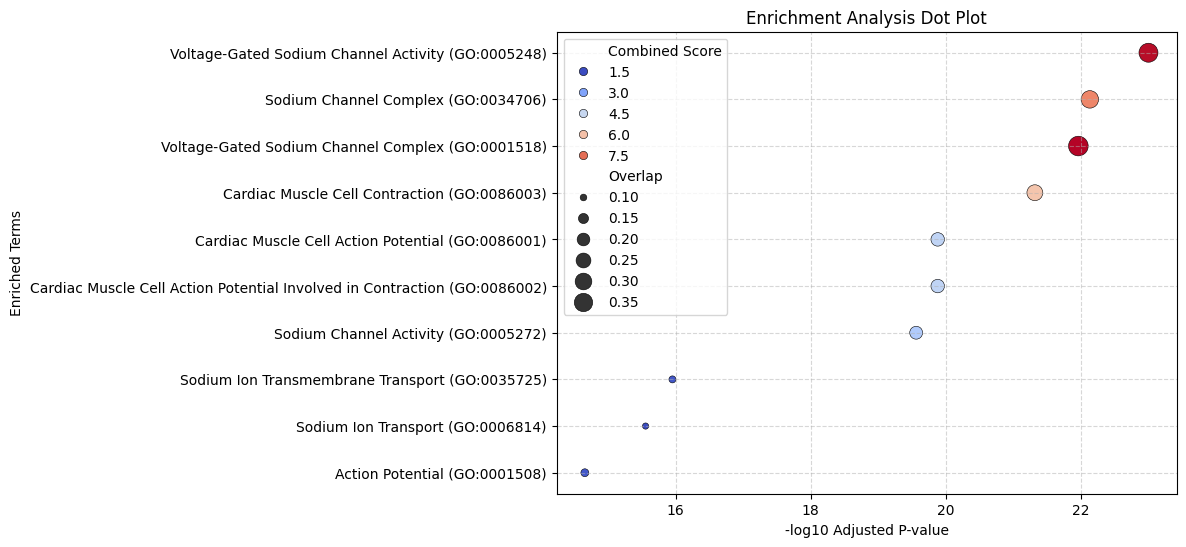

In [81]:
dotplot_gseapy(G_elma_icd_male_genetic_enrichment_dict[('K35','K37')])